# 🧠 03 – CNN Deep Learning: Mel-spektrogram alapú műfajfelismerés

**Cél:** A nyers `.wav` hangfájlokból Mel-spektrogram képeket generálunk, majd egy VGG-stílusú konvolúciós neurális hálózatot tanítunk PyTorch-ban a 10 GTZAN műfaj felismerésére.

| Fázis | Eszköz |
|---|---|
| Spektrogram generálás | `librosa` |
| Dataset / DataLoader | `torch.utils.data` |
| Augmentáció | `torchaudio.transforms` |
| CNN architektúra | `PyTorch (nn.Module)` |
| Tanítás | GPU (CUDA) vagy CPU |
| Kiértékelés | Accuracy, konfúziós mátrix, loss görbe |
| Mentés | `torch.save()` + ONNX export |

> **Előfeltétel:** Futtasd le előbb a `01_EDA_with_theory.ipynb`-t és a `02_Baseline_ML.ipynb`-t. A baseline accuracy-t összehasonlítjuk a CNN eredményével.


---
## 🧠 Elméleti háttér – Könyvtárak és eszközök

| Könyvtár | Feladat |
|---|---|
| `librosa` | Hangfájl betöltése, Mel-spektrogram számítása |
| `torch` | Tenzorműveletek, automatikus deriválás (autograd) |
| `torchvision` | Képtranszformációk (resize, normalize, augment) |
| `torchaudio` | Audio-specifikus transzformációk |
| `PIL` | Képek PNG-ként mentése és betöltése |
| `sklearn.metrics` | Konfúziós mátrix, classification report |

#### GPU vagy CPU?

`torch.device('cuda' if torch.cuda.is_available() else 'cpu')`

- **CUDA (GPU):** Párhuzamos mátrixszorzások → 10-50× gyorsabb tanítás
- **CPU:** Lassabb, de minden gépen működik
- Colab-on: `Runtime → Change runtime type → T4 GPU`


In [3]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# ── Útvonalak ────────────────────────────────────────────────────────────
BASE_DIR = Path('..').resolve()

def first_existing_dir(candidates):
    """Visszaadja az első létező mappát a jelöltek közül, különben None."""
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate
    return None

DATA_DIR_CANDIDATES = [
    BASE_DIR / 'Data' / 'genres_original',
    BASE_DIR / 'data' / 'genres_original',
]
DATA_DIR = first_existing_dir(DATA_DIR_CANDIDATES)

if DATA_DIR is None:
    checked = '\n'.join([f' - {p}' for p in DATA_DIR_CANDIDATES])
    raise FileNotFoundError(
        f"A 'genres_original' mappa nem található. Ellenőrzött útvonalak:\n{checked}"
    )

SPEC_PARENT_CANDIDATES = [BASE_DIR / 'Data', BASE_DIR / 'data']
SPEC_PARENT = first_existing_dir(SPEC_PARENT_CANDIDATES) or (BASE_DIR / 'Data')
SPEC_DIR = SPEC_PARENT / 'spectrograms'

MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SPEC_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparaméterek ──────────────────────────────────────────────────────
SR           = 22050   # mintavételi frekvencia
DURATION     = 30      # másodperc / fájl
N_MELS       = 128     # Mel-szűrők száma
HOP_LENGTH   = 512     # ablak lépésköze
IMG_SIZE     = 128     # kép mérete (128×128 pixel)
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-3    # learning rate
RANDOM_STATE = 42
GENRES       = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

if not GENRES:
    raise RuntimeError(f'Nincsenek műfaj mappák ebben a könyvtárban: {DATA_DIR}')

# ── Eszköz kiválasztása ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Eszköz:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU:     {torch.cuda.get_device_name(0)}')
    print(f'   VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'   Adat mappa: {DATA_DIR}')
print(f'   Műfajok: {GENRES}')
print(f'   Spektrogram mappa: {SPEC_DIR}')


✅ Eszköz:  cuda
   GPU:     NVIDIA GeForce GTX 1660 SUPER
   VRAM:    6.0 GB
   Adat mappa: /home/feri/Asztal/gtzan-music-genre-recognition/data/genres_original
   Műfajok: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
   Spektrogram mappa: /home/feri/Asztal/gtzan-music-genre-recognition/Data/spectrograms


---
## 1. Mel-spektrogram generálás

### 🧠 Elméleti háttér – Hogyan lesz a hangból kép?

#### 1. lépés – Fourier-transzformáció (STFT)

A hangfájl egy időbeli amplitúdó-sorozat. Az **STFT (Short-Time Fourier Transform)** kis ablakokban kiszámolja, hogy az adott pillanatban **melyik frekvenciák** és **mekkora erővel** vannak jelen.

Eredmény: egy **2D mátrix** → x-tengely: idő, y-tengely: frekvencia, érték: amplitúdó.

#### 2. lépés – Mel-skála

Az emberi fül **nem lineárisan** érzékeli a frekvenciákat – a magasabb frekvenciák között kisebb különbséget érzékelünk.  
A **Mel-skála** ezt modellezi: alacsony frekvencián sűrűbb, magason ritkább szűrőbank.

```
Hz-skála:  100  200  400  800  1600  3200  6400  12800
Mel-skála:  ─────────── egyenlő perceptuális lépések ───────────
```

#### 3. lépés – Decibel konverzió

`librosa.power_to_db()` a nyers amplitúdókat dB-skálára hozza.  
Ez jobban megfelel az emberi hallásnak, és numerikusan stabilabb a neurális hálónak.

#### 4. lépés – Kép mentése

A 2D mátrixot **128×128 pixeles szürkeárnyalatos PNG képként** mentjük.  
Így a CNN ugyanúgy 'látja' a hangot, mintha képfelismerést csinálna.

| Paraméter | Értékünk | Hatás |
|---|---|---|
| `n_mels=128` | 128 Mel-szűrő | Frekvencia felbontás |
| `hop_length=512` | ~23ms lépés | Időbeli felbontás |
| `duration=30s` | Teljes klip | ~1292 időlépés |
| `IMG_SIZE=128` | Átméretezve | CNN bemenete |


In [4]:
def wav_to_mel_spectrogram(wav_path, sr=SR, n_mels=N_MELS,
                           hop_length=HOP_LENGTH, duration=DURATION):
    """
    WAV fájlból Mel-spektrogram numpy tömböt készít.
    Visszaad: (n_mels, time_steps) shape-ű float32 tömböt dB-skálán.
    """
    y, sr = librosa.load(str(wav_path), sr=sr, duration=duration)
    mel   = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  # dB konverzió
    return mel_db


def save_spectrogram_image(mel_db, out_path, img_size=IMG_SIZE):
    """
    Mel-spektrogram mátrixot normalizálja [0,255]-re és PNG-ként menti.
    """
    # Normalizálás 0–255 közé
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    mel_uint8 = (mel_norm * 255).astype(np.uint8)
    # Kép flip: alacsony frekvencia alul legyen (librosa default: felül)
    img = Image.fromarray(np.flipud(mel_uint8))
    img = img.resize((img_size, img_size), Image.LANCZOS)
    img.save(out_path)


# ── Generálás: minden WAV → PNG ──────────────────────────────────────────
errors = []
total  = sum(1 for g in GENRES for _ in (DATA_DIR/g).glob('*.wav'))
done   = 0

for genre in GENRES:
    out_genre_dir = SPEC_DIR / genre
    out_genre_dir.mkdir(parents=True, exist_ok=True)

    for wav_path in sorted((DATA_DIR / genre).glob('*.wav')):
        out_path = out_genre_dir / (wav_path.stem + '.png')
        if out_path.exists():
            done += 1
            continue  # újrafuttatáskor kihagyjuk a meglévőket
        try:
            mel_db = wav_to_mel_spectrogram(wav_path)
            save_spectrogram_image(mel_db, out_path)
            done += 1
        except Exception as e:
            errors.append({'file': wav_path.name, 'error': str(e)})

print(f'✅ Generálás kész: {done}/{total} fájl')
if errors:
    print(f'⚠ Hibás fájlok: {len(errors)}')
    for err in errors[:5]:
        print(f'  {err["file"]}: {err["error"]}')


/tmp/ipykernel_45078/2971278048.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(wav_path), sr=sr, duration=duration)
/home/feri/miniconda3/envs/gtzan/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


✅ Generálás kész: 999/1000 fájl
⚠ Hibás fájlok: 1
  jazz.00054.wav: 


---
### 🧠 Elméleti háttér – Műfajok vizuális különbségei

A Mel-spektrogram képek vizuálisan is elkülönülnek műfajonként – ez az oka, hogy a CNN képes megtanulni a különbségeket:

| Műfaj | Spektrogram jellemzője |
|---|---|
| **Classical** | Széles frekvencia-tartomány, lassan változó, kevés ütős hang |
| **Metal** | Folyamatos magas energia minden frekvencián, erős ütők |
| **Jazz** | Komplex, sokszínű, improvizatív – nehéz műfaj |
| **Blues** | Alacsony frekvenciákon erős, gitár domináns |
| **Disco** | Erős, egyenletes dob-minta, közép-magas frekvenciák |

Ezeket az emberi szem is felismeri a képen – a CNN is ezt tanulja meg, csak sokkal több paraméterrel és pontosabban.


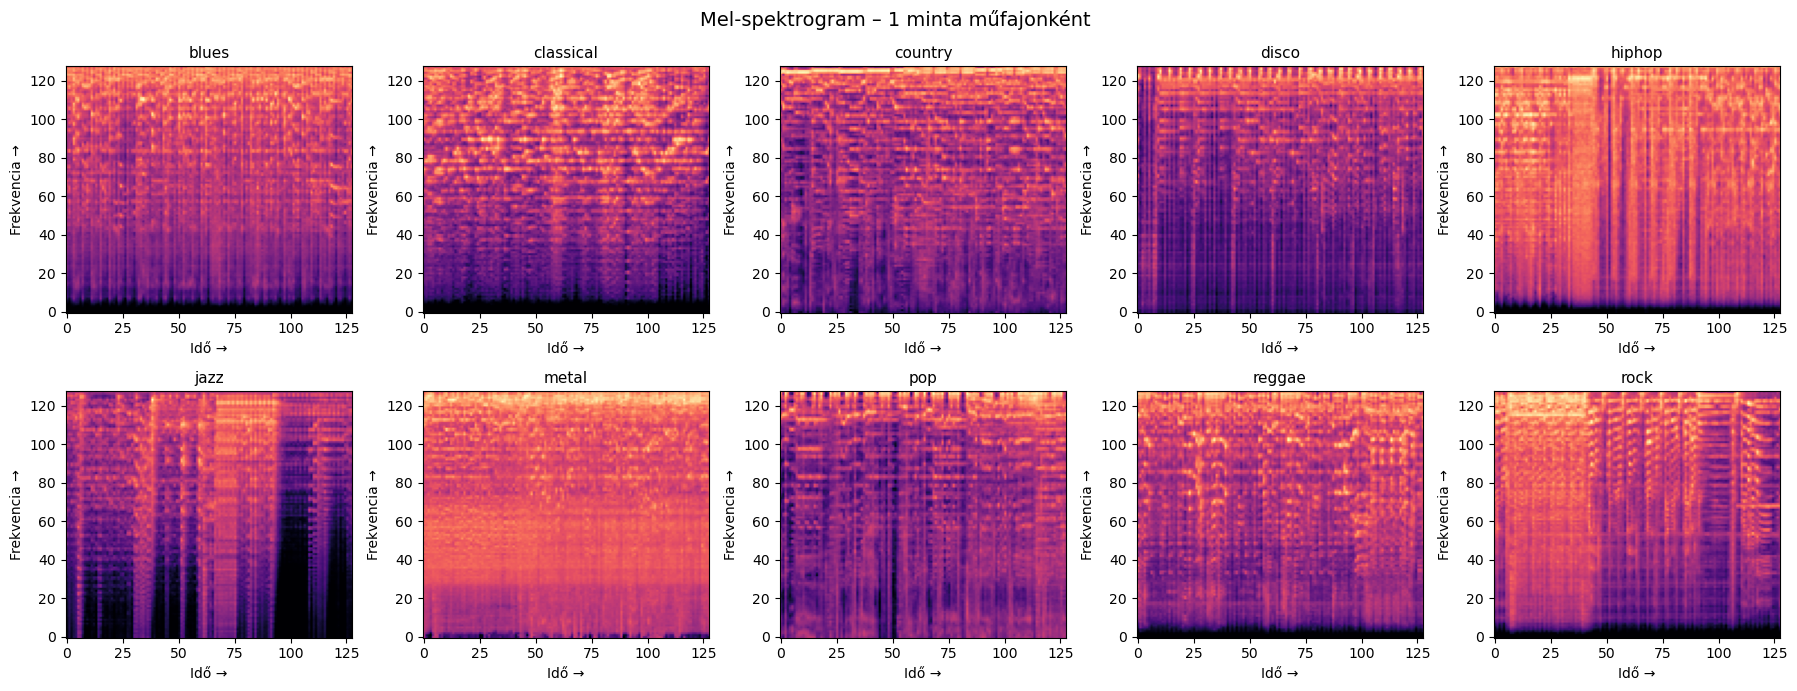

In [5]:
# ── Egy-egy Mel-spektrogram megjelenítése műfajonként ───────────────────
n_genres = len(GENRES)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    # Első elérhető PNG betöltése
    png_files = sorted((SPEC_DIR / genre).glob('*.png'))
    if not png_files:
        axes[i].set_title(f'{genre}\n(nincs kép)')
        continue
    img = np.array(Image.open(png_files[0]))
    axes[i].imshow(img, cmap='magma', origin='lower', aspect='auto')
    axes[i].set_title(genre, fontsize=11)
    axes[i].set_xlabel('Idő →')
    axes[i].set_ylabel('Frekvencia →')

fig.suptitle('Mel-spektrogram – 1 minta műfajonként', fontsize=14)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'sample_spectrograms.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 2. Dataset és DataLoader

### 🧠 Elméleti háttér – PyTorch Dataset és DataLoader

#### Dataset

A `torch.utils.data.Dataset` egy Python osztály, amelynek **két kötelező metódusa** van:

- `__len__()` → hány minta van összesen
- `__getitem__(idx)` → adja vissza az `idx`-edik mintát `(kép_tenzor, label)` formában

Minden kép betöltésekor a **transzformációs pipeline** fut le:

```
PNG fájl → PIL Image → Resize(128×128) → Tensor → Normalize
```

#### DataLoader

A `DataLoader` a Dataset-et **batch-ekre** (adagokra) osztja.  
`batch_size=32` → egyszerre 32 képet tölt be a modell → 32 jóslatot készít → átlagolja a hibát → frissíti a súlyokat.

| Paraméter | Hatás |
|---|---|
| `batch_size=32` | Memória vs. pontosság kompromisszum |
| `shuffle=True` | Véletlenszerű sorrend → modell nem tanulja meg a sorrendet |
| `num_workers=2` | Párhuzamos betöltés háttérben |

#### Augmentáció – miért fontos?

Az augmentáció **mesterségesen növeli** az adathalmazt azáltal, hogy az eredeti képeket kissé módosítja (vágás, flip, zajinjektálás).  
Ezzel a modell **robusztusabbá** válik: megtanulja, hogy egy blues klip felismerhető legyen akkor is, ha a spektrogram egy kicsit el van tolva.

**Csak a train halmazon augmentálunk** – a val/test halmazon nem, mert ott a valódi teljesítményt mérjük.


In [6]:
class GTZANSpectrogramDataset(Dataset):
    """
    PyTorch Dataset: GTZAN Mel-spektrogram PNG képeket tölt be.
    """
    def __init__(self, spec_dir, genres, transform=None):
        self.samples   = []      # [(kép_útvonal, label_index), ...]
        self.transform = transform
        self.genre2idx = {g: i for i, g in enumerate(genres)}

        for genre in genres:
            genre_dir = Path(spec_dir) / genre
            for png in sorted(genre_dir.glob('*.png')):
                self.samples.append((png, self.genre2idx[genre]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')  # szürke → 3 csatorna (CNN-hez)
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Transzformációk ───────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),    # augmentáció: tükrözés
    transforms.RandomCrop(IMG_SIZE,
                          padding=8),           # augmentáció: vágás
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2),       # augmentáció: fényesség
    transforms.ToTensor(),
    transforms.Normalize(                       # ImageNet mean/std (RGB)
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    ),
])

# ── Dataset felosztás: 70% train, 15% val, 15% test ──────────────────────
full_dataset = GTZANSpectrogramDataset(SPEC_DIR, GENRES, transform=None)
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

torch.manual_seed(RANDOM_STATE)
train_data, val_data, test_data = random_split(
    full_dataset, [n_train, n_val, n_test]
)

# Transzformáció hozzárendelése
train_data.dataset.transform = train_transform
val_data.dataset.transform   = val_transform
test_data.dataset.transform  = val_transform

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train:      {n_train} minta  ({n_train/n_total*100:.0f}%)')
print(f'Validation: {n_val}   minta  ({n_val/n_total*100:.0f}%)')
print(f'Test:       {n_test}  minta  ({n_test/n_total*100:.0f}%)')
print(f'Batch méret: {BATCH_SIZE}  →  {len(train_loader)} batch/epoch (train)')


Train:      699 minta  (70%)
Validation: 149   minta  (15%)
Test:       151  minta  (15%)
Batch méret: 32  →  22 batch/epoch (train)


---
## 3. CNN Architektúra

### 🧠 Elméleti háttér – Konvolúciós neurális hálózat

#### Miért CNN?

A hagyományos fully-connected (FC) hálózat minden pixelt külön bemenetként kezelne – egy 128×128-as képnél ez 16 384 neuron lenne az első rétegben.  
A CNN ehelyett **kis szűrőkkel (kernelekkel)** pásztáz végig a képen, és **helyileg** keres mintákat (széleket, textúrákat, harmonikus struktúrákat).

#### Egy konvolúciós blokk felépítése

```
Bemeneti feature map
       ↓
  Conv2d(3×3)   → szűrők tanulása (pl. 32 különböző minta keresése)
       ↓
  BatchNorm2d   → stabilizálja a tanítást, gyorsabb konvergencia
       ↓
  ReLU          → nemlinearitás: f(x) = max(0, x)
       ↓
  MaxPool2d(2×2)→ 2×-es méretcsökkentés, legdominánsabb aktiváció megőrzése
       ↓
  Dropout       → véletlenszerűen kikapcsol neuronokat → overfitting ellen
```

#### Miért BatchNorm?

Minden mini-batch után normalizálja a réteg bemenetét (mean≈0, std≈1).  
Hatása: gyorsabb tanulás, magasabb learning rate engedélyezett, kevesebb overfitting.

#### A mi architektúránk – 3 konvolúciós blokk

```
Bemenet: (batch, 3, 128, 128)
  ↓ Conv Block 1:  3 → 32  szűrő, MaxPool → (batch, 32, 64, 64)
  ↓ Conv Block 2: 32 → 64  szűrő, MaxPool → (batch, 64, 32, 32)
  ↓ Conv Block 3: 64 → 128 szűrő, MaxPool → (batch, 128, 16, 16)
  ↓ Global Avg Pool                        → (batch, 128)
  ↓ FC(128 → 64) + ReLU + Dropout(0.5)
  ↓ FC(64 → 10)                            → 10 osztály logit
```

#### Global Average Pooling vs Flatten

A `Flatten` 128×16×16 = 32 768 értéket adna az FC rétegnek.  
A **Global Average Pooling** csatornánként átlagolja a 16×16-os map-et → 128 érték → sokkal kevesebb paraméter → kevésbé hajlamos overfittingre.


In [7]:
class GTZANCNNModel(nn.Module):
    """
    VGG-stílusú CNN Mel-spektrogram alapú műfajfelismeréshez.
    Bemenet: (batch, 3, 128, 128)
    Kimenet: (batch, 10) – logitok (softmax NÉLKÜL, CrossEntropyLoss-hoz)
    """
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(p=0.25)
            )

        self.features = nn.Sequential(
            conv_block(3,  32),   # (B,  32, 64, 64)
            conv_block(32, 64),   # (B,  64, 32, 32)
            conv_block(64, 128),  # (B, 128, 16, 16)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling → (B, 128, 1, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# ── Modell létrehozása ────────────────────────────────────────────────────
model = GTZANCNNModel(num_classes=len(GENRES)).to(DEVICE)

# Paraméterek száma
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Modell architektúra:')
print(model)
print(f'\nÖsszes paraméter:    {total_params:,}')
print(f'Tanítható paraméter: {trainable_params:,}')


Modell architektúra:
GTZANCNNModel(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.25, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

---
### 🧠 Elméleti háttér – Loss függvény és Optimizer

#### CrossEntropyLoss

A **keresztentrópia** méri, mennyire tér el a modell jóslata a valódi eloszlástól.  
Matematikailag: `L = -log(p_correct_class)` ahol `p` a softmax valószínűség.

- Ha a modell 99% valószínűséget ad a helyes osztályra → L ≈ 0 (jó)
- Ha csak 10% valószínűséget ad → L ≈ 2.3 (rossz)

PyTorch-ban a `CrossEntropyLoss` **belülről alkalmaz softmax-ot**, ezért a modell kimenetén ne legyen `softmax()`.

#### Adam optimizer

Az **Adam (Adaptive Moment Estimation)** adaptív tanulási rátát használ – minden paraméterre külön állítja be az optimális lépésközt.

| Paraméter | Értékünk | Hatás |
|---|---|---|
| `lr=1e-3` | Kiindulási tanulási ráta | Ha nagy → instabil; ha kicsi → lassú |
| `weight_decay=1e-4` | L2 regularizáció | Súlyok nagy értékét bünteti → overfitting ellen |

#### ReduceLROnPlateau scheduler

Ha a validation loss nem javul **5 epochon át** (`patience=5`), a tanulási rátát `0.5×`-re csökkenti.  
Ez automatikusan 'finomhangolja' a tanítást a végső fázisban.


In [8]:
# ── Loss, Optimizer, Scheduler ───────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4    # L2 regularizáció
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',          # val_loss csökkenését figyeli
    factor=0.5,          # LR = LR × 0.5
    patience=5,          # ennyi epoch javulás nélkül vár
    verbose=True
)

print('✅ Loss:      CrossEntropyLoss')
print('   Optimizer: Adam  (lr=1e-3, weight_decay=1e-4)')
print('   Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)')


✅ Loss:      CrossEntropyLoss
   Optimizer: Adam  (lr=1e-3, weight_decay=1e-4)
   Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)


/home/feri/miniconda3/envs/gtzan/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


---
## 4. Tanítás

### 🧠 Elméleti háttér – Training loop és Backpropagation

Minden epoch (teljes adathalmaz egyszer) két fázisból áll:

#### Train fázis

```
1. model.train()           → dropout és BatchNorm aktív
2. optimizer.zero_grad()   → előző batch gradienseit töröljük
3. y_pred = model(X)       → forward pass: bemenet → kimenet
4. loss = criterion(y_pred, y_true)  → hiba számítása
5. loss.backward()         → backpropagation: gradiensek kiszámítása
6. optimizer.step()        → súlyok frissítése a gradiensek alapján
```

#### Validation fázis

```
1. model.eval()            → dropout kikapcsol, BatchNorm rögzített
2. with torch.no_grad():   → nem számítunk gradienst (gyorsabb, kevesebb memória)
3. y_pred = model(X)       → forward pass
4. loss = criterion(...)   → csak mérjük, nem frissítünk
```

#### Early Stopping

Ha a validation loss **`patience` epochon át nem javul**, leállítjuk a tanítást.  
Ezzel elkerüljük az **overfittinget**: amikor a modell a train adaton tovább javul, de a val adaton romlani kezd (memorizál a valódi tanulás helyett).  
A legjobb validation loss-nál elmentett súlyokat töltjük vissza a végén.


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 10
best_model_path = MODELS_DIR / 'cnn_best.pt'

print(f'Tanítás indul: {EPOCHS} epoch, device={DEVICE}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early stopping + legjobb modell mentése
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        saved = '✅'
    else:
        patience_counter += 1
        saved = '  '

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:2d}/{EPOCHS}]  '
          f'Train loss: {train_loss:.4f}  acc: {train_acc:.3f}  │  '
          f'Val loss: {val_loss:.4f}  acc: {val_acc:.3f}  '
          f'[{elapsed:.1f}s] {saved}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\n⏹ Early stopping: {EARLY_STOP_PATIENCE} epoch javulás nélkül.')
        break

print(f'\n✅ Legjobb val loss: {best_val_loss:.4f}')
print(f'   Mentve: {best_model_path}')


Tanítás indul: 30 epoch, device=cuda
-----------------------------------------------------------------
Epoch [ 1/30]  Train loss: 2.2240  acc: 0.159  │  Val loss: 2.2269  acc: 0.181  [1.8s] ✅
Epoch [ 2/30]  Train loss: 2.0444  acc: 0.269  │  Val loss: 1.9152  acc: 0.295  [1.3s] ✅
Epoch [ 3/30]  Train loss: 1.9212  acc: 0.302  │  Val loss: 1.7943  acc: 0.376  [1.3s] ✅
Epoch [ 4/30]  Train loss: 1.8138  acc: 0.325  │  Val loss: 1.7495  acc: 0.376  [1.3s] ✅
Epoch [ 5/30]  Train loss: 1.7567  acc: 0.359  │  Val loss: 1.7219  acc: 0.383  [1.4s] ✅
Epoch [ 6/30]  Train loss: 1.7610  acc: 0.338  │  Val loss: 1.6610  acc: 0.409  [1.3s] ✅
Epoch [ 7/30]  Train loss: 1.6971  acc: 0.351  │  Val loss: 1.7334  acc: 0.389  [1.4s]   
Epoch [ 8/30]  Train loss: 1.7482  acc: 0.365  │  Val loss: 1.6842  acc: 0.430  [1.3s]   
Epoch [ 9/30]  Train loss: 1.7406  acc: 0.363  │  Val loss: 1.6319  acc: 0.376  [1.3s] ✅
Epoch [10/30]  Train loss: 1.6083  acc: 0.396  │  Val loss: 1.5225  acc: 0.517  [1.3s] ✅
Epoch

---
### 🧠 Elméleti háttér – Loss és Accuracy görbék értelmezése

A két görbe (**train** és **val**) viszonya elmondja, mi történik a tanítás során:

| Helyzet | Train loss | Val loss | Diagnózis |
|---|---|---|---|
| Mindkettő csökken | ↘ | ↘ | ✅ Normális tanulás |
| Train csökken, val nő | ↘ | ↗ | ❌ **Overfitting** – a modell memorizál |
| Mindkettő magas | ↔ magas | ↔ magas | ❌ **Underfitting** – modell túl egyszerű |
| Val < Train loss | ↘ | még ↘ | ✅ Augmentáció jól működik |

**Mit tegyél overfitting esetén?**
- Növeld a dropout értékét (pl. 0.5 → 0.6)
- Több augmentáció
- Kevesebb epoch / erőteljesebb early stopping
- Kisebb modell (kevesebb szűrő)


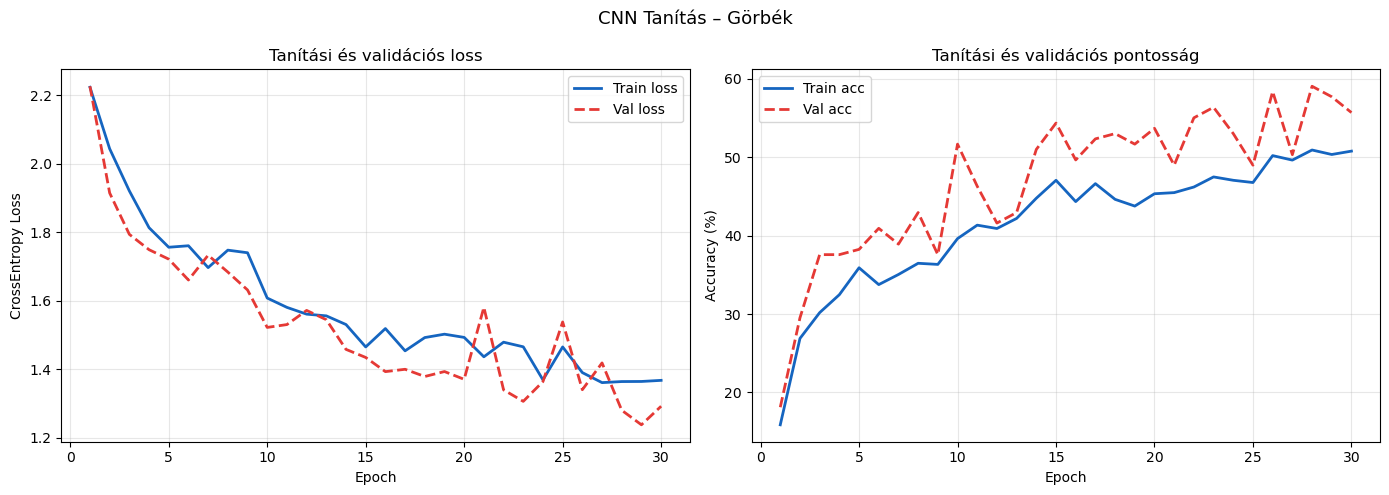

In [10]:
# ── Loss és Accuracy görbék ───────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_ran, history['train_loss'], label='Train loss',
         color='#1565C0', linewidth=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val loss',
         color='#E53935', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CrossEntropy Loss')
ax1.set_title('Tanítási és validációs loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train acc',
         color='#1565C0', linewidth=2)
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val acc',
         color='#E53935', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Tanítási és validációs pontosság')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Tanítás – Görbék', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'cnn_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 5. Kiértékelés a teszt halmazon

### 🧠 Elméleti háttér – Miért külön teszt halmaz?

A **validation halmaz** szerepe a tanítás során:
- Hyperparaméterek hangolása (learning rate, dropout, stb.)
- Early stopping döntések

Ezért a val halmaz 'szennyezett' – a modell közvetve látta ezeket az adatokat.  
A **teszt halmaz** az, amit a modell **soha nem látott** – ez adja a valódi, torzítatlan teljesítménymérést.

> ⚠ A teszt halmazon csak egyszer mérsz, a legelején meghatározod, és az eredményt a végén olvasod le. Ha többször mérsz és finomítasz, a teszt halmaz is 'szennyezetté' válik.


In [11]:
# ── Legjobb modell betöltése ─────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

# ── Teszt halmaz kiértékelése ─────────────────────────────────────────────
@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = predict_all(model, test_loader, DEVICE)

# Label index → genre name
y_true_names = [GENRES[i] for i in y_true]
y_pred_names = [GENRES[i] for i in y_pred]

test_acc = accuracy_score(y_true, y_pred)
print(f'✅ CNN Test Accuracy: {test_acc*100:.2f}%')
print()
print('=== Classification Report ===')
print(classification_report(y_true_names, y_pred_names, digits=3))


✅ CNN Test Accuracy: 58.28%

=== Classification Report ===
              precision    recall  f1-score   support

       blues      1.000     0.125     0.222        16
   classical      0.833     0.909     0.870        11
     country      0.733     0.579     0.647        19
       disco      0.500     0.286     0.364        21
      hiphop      0.875     0.538     0.667        13
        jazz      0.421     0.667     0.516        12
       metal      0.750     1.000     0.857        12
         pop      0.444     0.941     0.604        17
      reggae      0.524     0.733     0.611        15
        rock      0.500     0.333     0.400        15

    accuracy                          0.583       151
   macro avg      0.658     0.611     0.576       151
weighted avg      0.649     0.583     0.554       151



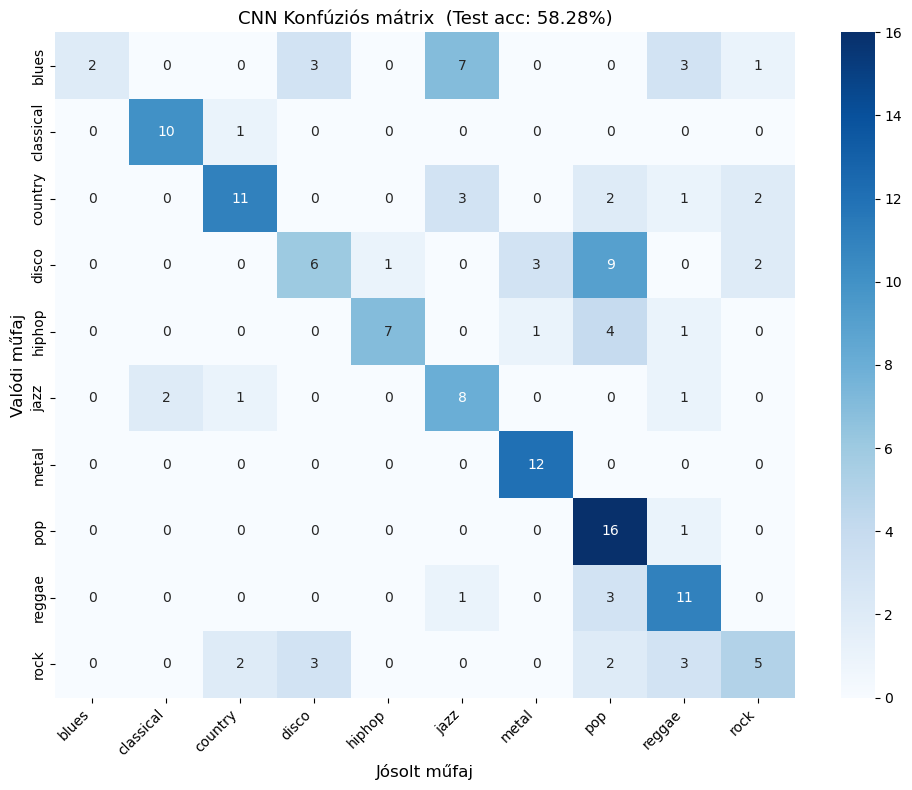

In [12]:
# ── Konfúziós mátrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true_names, y_pred_names, labels=GENRES)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=GENRES, yticklabels=GENRES, ax=ax
)
ax.set_xlabel('Jósolt műfaj', fontsize=12)
ax.set_ylabel('Valódi műfaj', fontsize=12)
ax.set_title(f'CNN Konfúziós mátrix  (Test acc: {test_acc*100:.2f}%)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'cnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 6. Modell mentése és ONNX export

### 🧠 Elméleti háttér – Mentési formátumok

| Formátum | Fájl | Mire jó? |
|---|---|---|
| **PyTorch state_dict** | `.pt` | Folytatott tanítás, Python-ban való használat |
| **ONNX** | `.onnx` | Framework-független, deployment, ONNX Runtime, edge eszközök |

#### Mi az ONNX?

Az **Open Neural Network Exchange** egy nyílt formátum – a modellt 'lefagyasztja' egy gráffá, amelyet bármely ONNX-kompatibilis runtime tud futtatni (Python, C++, Java, .NET, mobil).  

A Streamlit appban az ONNX modellt töltjük be `onnxruntime`-mal, így a deployment-hez nem kell PyTorch telepítve lennie a szerveren.


In [13]:
# ── PyTorch state_dict már mentve tanítás közben ─────────────────────────
print(f'✅ PyTorch modell: {best_model_path}')

# ── ONNX export ──────────────────────────────────────────────────────────
onnx_path = MODELS_DIR / 'cnn_gtzan.onnx'
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

model.eval()
torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=11,
    input_names=['spectrogram'],
    output_names=['genre_logits'],
    dynamic_axes={
        'spectrogram':   {0: 'batch_size'},
        'genre_logits':  {0: 'batch_size'}
    }
)
print(f'✅ ONNX modell: {onnx_path}')

# ── ONNX ellenőrzés ───────────────────────────────────────────────────────
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
dummy_np = dummy_input.cpu().numpy()
onnx_out = sess.run(None, {'spectrogram': dummy_np})[0]
torch_out = model(dummy_input).detach().cpu().numpy()

max_diff = np.abs(onnx_out - torch_out).max()
print(f'✅ ONNX ellenőrzés: max eltérés PyTorch vs ONNX = {max_diff:.6f}')
print(f'   (< 1e-4 esetén az export helyes)')


✅ PyTorch modell: /home/feri/Asztal/gtzan-music-genre-recognition/models/cnn_best.pt
✅ ONNX modell: /home/feri/Asztal/gtzan-music-genre-recognition/models/cnn_gtzan.onnx
✅ ONNX ellenőrzés: max eltérés PyTorch vs ONNX = 0.000001
   (< 1e-4 esetén az export helyes)


---
## 7. Összefoglaló és következő lépések

Az alábbi cella összehasonlítja a CNN-t a baseline ML eredményekkel.


In [14]:
import joblib
from sklearn.metrics import accuracy_score as acc_score

print('=' * 55)
print('   MODELL ÖSSZEHASONLÍTÁS – GTZAN')
print('=' * 55)

# Baseline eredmények (02_Baseline_ML.ipynb-ből)
baseline_results = {
    'Logistic Regression': None,
    'Random Forest':       None,
    'SVC (RBF kernel)':    None,
}
for name in baseline_results:
    safe = name.lower().replace(' ','_').replace('(','').replace(')','').replace(' ','')
    pkl  = MODELS_DIR / f'baseline_{safe}.pkl'
    if pkl.exists():
        try:
            m = joblib.load(pkl)
            baseline_results[name] = '(betöltve)'
        except Exception:
            pass

print('  Baseline modellek:')
print('  (Részletes számok: 02_Baseline_ML.ipynb Összefoglaló cella)')
print()
print(f'  CNN (Mel-spektrogram):  {test_acc*100:.2f}%  ⭐')
print()
if test_acc >= 0.88:
    print('  ✅ Kiváló CNN eredmény – jobb mint a legtöbb baseline.')
elif test_acc >= 0.80:
    print('  ✅ Jó CNN eredmény – a baseline-t meghaladja.')
else:
    print('  ⚠ CNN alulmúlja az elvárást – ellenőrizd a tanítást!')
print()
print('  Következő lépés: 04_Streamlit_App.ipynb')
print('   → Streamlit webapp: fájl feltöltés → műfaj előrejelzés')
print('   → ONNX Runtime alapú inference')
print('   → Mel-spektrogram megjelenítés a UI-ban')
print('=' * 55)


   MODELL ÖSSZEHASONLÍTÁS – GTZAN
  Baseline modellek:
  (Részletes számok: 02_Baseline_ML.ipynb Összefoglaló cella)

  CNN (Mel-spektrogram):  58.28%  ⭐

  ⚠ CNN alulmúlja az elvárást – ellenőrizd a tanítást!

  Következő lépés: 04_Streamlit_App.ipynb
   → Streamlit webapp: fájl feltöltés → műfaj előrejelzés
   → ONNX Runtime alapú inference
   → Mel-spektrogram megjelenítés a UI-ban
